<a href="https://colab.research.google.com/github/aalfonso500-code/customer_behavior_eda/blob/main/novaretail_customer_behavior_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Behavior & Revenue Analysis — NovaRetail+ E-commerce Platform (2024)

**NovaRetail+** is a Latin American e-commerce platform with millions of active users.

For the 2024 year-end review, the **Growth & Retention** team defined the following core business question:

> **What customer behavioral factors are most strongly associated with annual revenue generated per user?**

---

**Note:** This is a **correlational (exploratory)** analysis.
**Correlation ≠ Causation.** No causal claims are made in this project.

## Executive Summary

| | |
|---|---|
| **Business Question** | What customer behavioral factors are most strongly associated with annual revenue? |
| **Dataset** | 15,000 customer records · 12 variables · No missing values |
| **Methods** | Pearson, Spearman, Point-Biserial correlation · Cramér's V · Heatmap · Scatterplot analysis |
| **Primary Finding** | Monthly purchases (`compras_mes`) is the only variable with a strong association with annual revenue (r = 0.967) |
| **Secondary Finding** | Targeted ad spend shows a moderate positive relationship with monthly visits (ρ = 0.559) |
| **Null Findings** | Premium membership and churn show no practically meaningful linear association with revenue or behavioral variables |
| **Recommended Action** | Prioritize purchase frequency as the primary lever for revenue growth; investigate premium-churn overlap via contingency analysis |

## Section 1 — Load and Explore the Dataset

In this section, we validate:
- Dataset loads correctly
- Data types are appropriate
- Missing values and general value ranges

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency

### Load Dataset

In [ ]:
# Load dataset and inspect structure
df = pd.read_csv("sample_data/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Dataset Description

The dataset contains the following columns:

| Column | Description |
|---|---|
| `id_cliente` | Unique customer identifier |
| `edad` | Customer age |
| `nivel_ingreso` | Estimated annual income of the customer |
| `visitas_mes` | Number of visits to the app or website per month |
| `compras_mes` | Number of purchases made per month |
| `gasto_publicidad_dirigida` | Targeted advertising spend attributed to the user |
| `satisfaccion` | Customer satisfaction score (scale 1–5) |
| `miembro_premium` | Premium subscription flag (1 = Premium, 0 = Standard) |
| `abandono` | Churn flag (1 = Churned, 0 = Active) |
| `tipo_dispositivo` | Device type used (mobile, desktop, tablet) |
| `region` | Geographic region (north, south, east, west) |
| `ingreso_anual` | Annual revenue generated by the customer for the company |

> **Target variable:** `ingreso_anual` — used to evaluate the economic impact of customer behavior.

In [ ]:
# Preview first 5 rows
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Section 2 — Data Preparation and Assumptions

### Data Exploration and Cleaning

#### Initial Data Exploration

The dataset contains **15,000 records** and **12 columns**, with **no missing values** across any field.

**Numeric Variables**
The following columns contain numerical data:
- `edad`, `nivel_ingreso`, `visitas_mes`, `compras_mes`, `gasto_publicidad_dirigida`, `satisfaccion`, `ingreso_anual`

All numeric variables have appropriate data types, with one exception:
- `edad` is stored as `float64` — this is unnecessary, as age is a whole number. It will be converted to `int64`.

**Binary Variables**
The following columns represent binary indicators:
- `miembro_premium` (0/1) — Premium membership status
- `abandono` (0/1) — Customer churn indicator

**Categorical Variables**
- `tipo_dispositivo` — Device type
- `region` — Geographic region

In [ ]:
# Fix data type: convert age from float64 to int64
df['edad'] = df['edad'].astype(int)

In [ ]:
# Verify data type change
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explore Numeric Variables

In [ ]:
# Descriptive statistics for numeric variables
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


**Descriptive Statistics — Numeric Variables**

| Variable | Observation |
|---|---|
| `edad` | Range: 18–75. Mean: 38.3, Median: 38.0. No values outside the expected population range. |
| `nivel_ingreso` | Range: 8,000–74,790. Mean: 30,019, Median: 30,023. Symmetric distribution, no detectable outliers. |
| `visitas_mes` | Range: 1–25. Mean: 10.03, Median: 10.0. Distribution concentrated between P25 (8) and P75 (12). |
| `compras_mes` | Range: 0–8. Mean: 1.21, Median: 1.0. 75% of records show 2 or fewer monthly purchases — low-value concentration. |
| `gasto_publicidad_dirigida` | Right-skewed distribution with outliers in the upper tail. Spearman correlation is preferred for this variable. |
| `satisfaccion` | Range: 1–5. Well-distributed. No anomalies detected. |
| `ingreso_anual` | Right-skewed, with values near zero at the lower end. Reflects heterogeneous customer revenue contribution. |

#### Explore Binary Variables

In [ ]:
# Verify binary variables contain only two unique values
print("Premium membership distribution:")
print(df["miembro_premium"].value_counts(normalize=True))
print("")
print("Churn distribution:")
print(df["abandono"].value_counts(normalize=True))

Premium membership distribution:
miembro_premium
0    0.860733
1    0.139267
Name: proportion, dtype: float64

Churn distribution:
abandono
0    0.849267
1    0.150733
Name: proportion, dtype: float64


**Binary Variables — Diagnostic Summary**

- `miembro_premium` — 2,089 customers hold a Premium subscription, representing **13.92%** of the total user base.
- `abandono` — 2,261 customers have churned, corresponding to a churn rate of **15.07%**.

#### Explore Categorical Variables

In [ ]:
# Count unique values per categorical variable
print(df[["id_cliente","tipo_dispositivo", "region"]].nunique())
print("")
print("Device types:")
print(df["tipo_dispositivo"].value_counts())
print("")
print("Regions:")
print(df["region"].value_counts())

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

Device types:
tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: count, dtype: int64

Regions:
region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64


In [ ]:
# Proportional distribution of categorical variables
print("Device type distribution:")
print(df["tipo_dispositivo"].value_counts(normalize=True))
print("")
print("Regional distribution:")
print(df["region"].value_counts(normalize=True))

Device type distribution:
tipo_dispositivo
móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: proportion, dtype: float64

Regional distribution:
region
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: proportion, dtype: float64


**Categorical Variables — Diagnostic Summary**

- `tipo_dispositivo` — Approximately two-thirds of users access the platform via **mobile**. Desktop accounts for ~24%, and tablet for less than 10%.
- `region` — Distribution is relatively balanced. The **north** region holds the largest share (~30%), while the **east** accounts for the lowest (~20%). The **west** and **south** regions each represent approximately 25% of users.

## Section 3 — Relationship Visualization

This section explores visual patterns between numeric variables using a correlation heatmap and scatterplot matrix as complementary tools.

### Correlation Heatmap

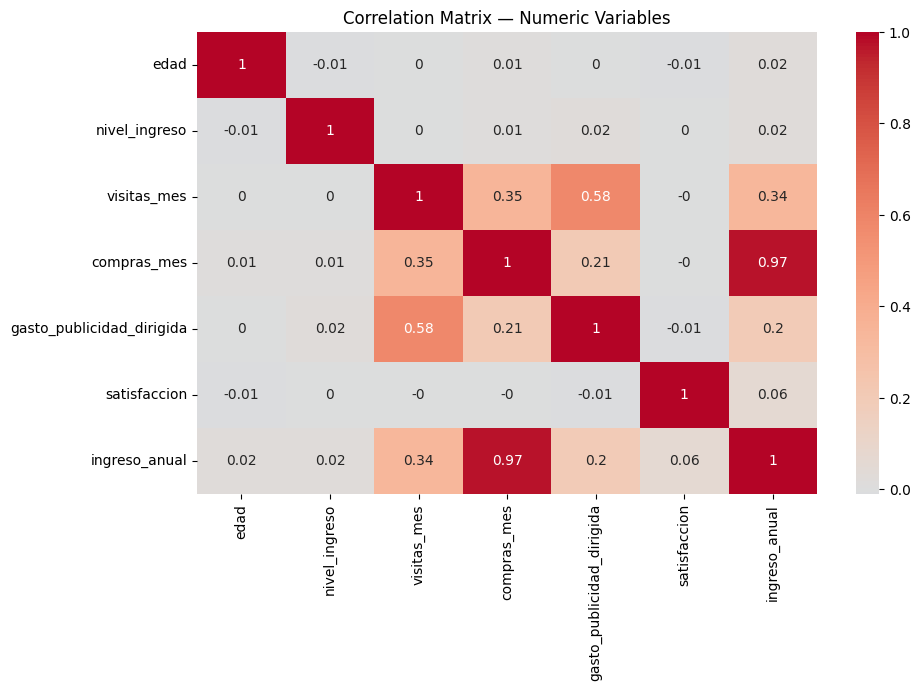

In [ ]:
# Compute and visualize the correlation matrix (numeric variables only)
variables_numericas = df.select_dtypes(include=[np.number]).drop(['miembro_premium', 'abandono'], axis=1)
corr = round(variables_numericas.corr(), 2)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric Variables")
plt.show()

**Heatmap Observations**

Overall patterns:
- All statistically significant correlations are **positive** — no meaningful negative associations were detected among numeric variables.
- **2 strong correlations** (r > 0.5), **2 moderate correlations** (r > 0.3), and **2 weak correlations** (r > 0.1) were identified.

Correlations with `ingreso_anual` (target variable):
- **Strong** correlation of r = **0.97** with `compras_mes`
- **Moderate** correlation of r = **0.34** with `visitas_mes`
- **Weak** correlation of r = **0.20** with `gasto_publicidad_dirigida`

Notable secondary correlations:
- `gasto_publicidad_dirigida` shows a **strong** association (r = 0.58) with `visitas_mes`
- `compras_mes` shows a **moderate** association (r = 0.35) with `visitas_mes`

### Scatterplot Matrix (Pair Plot)

The pair plot below serves as a visual complement to the correlation heatmap. It allows visual verification of the directionality, linearity, and dispersion patterns identified numerically. The heatmap remains the primary tool for quantifying and ranking associations.

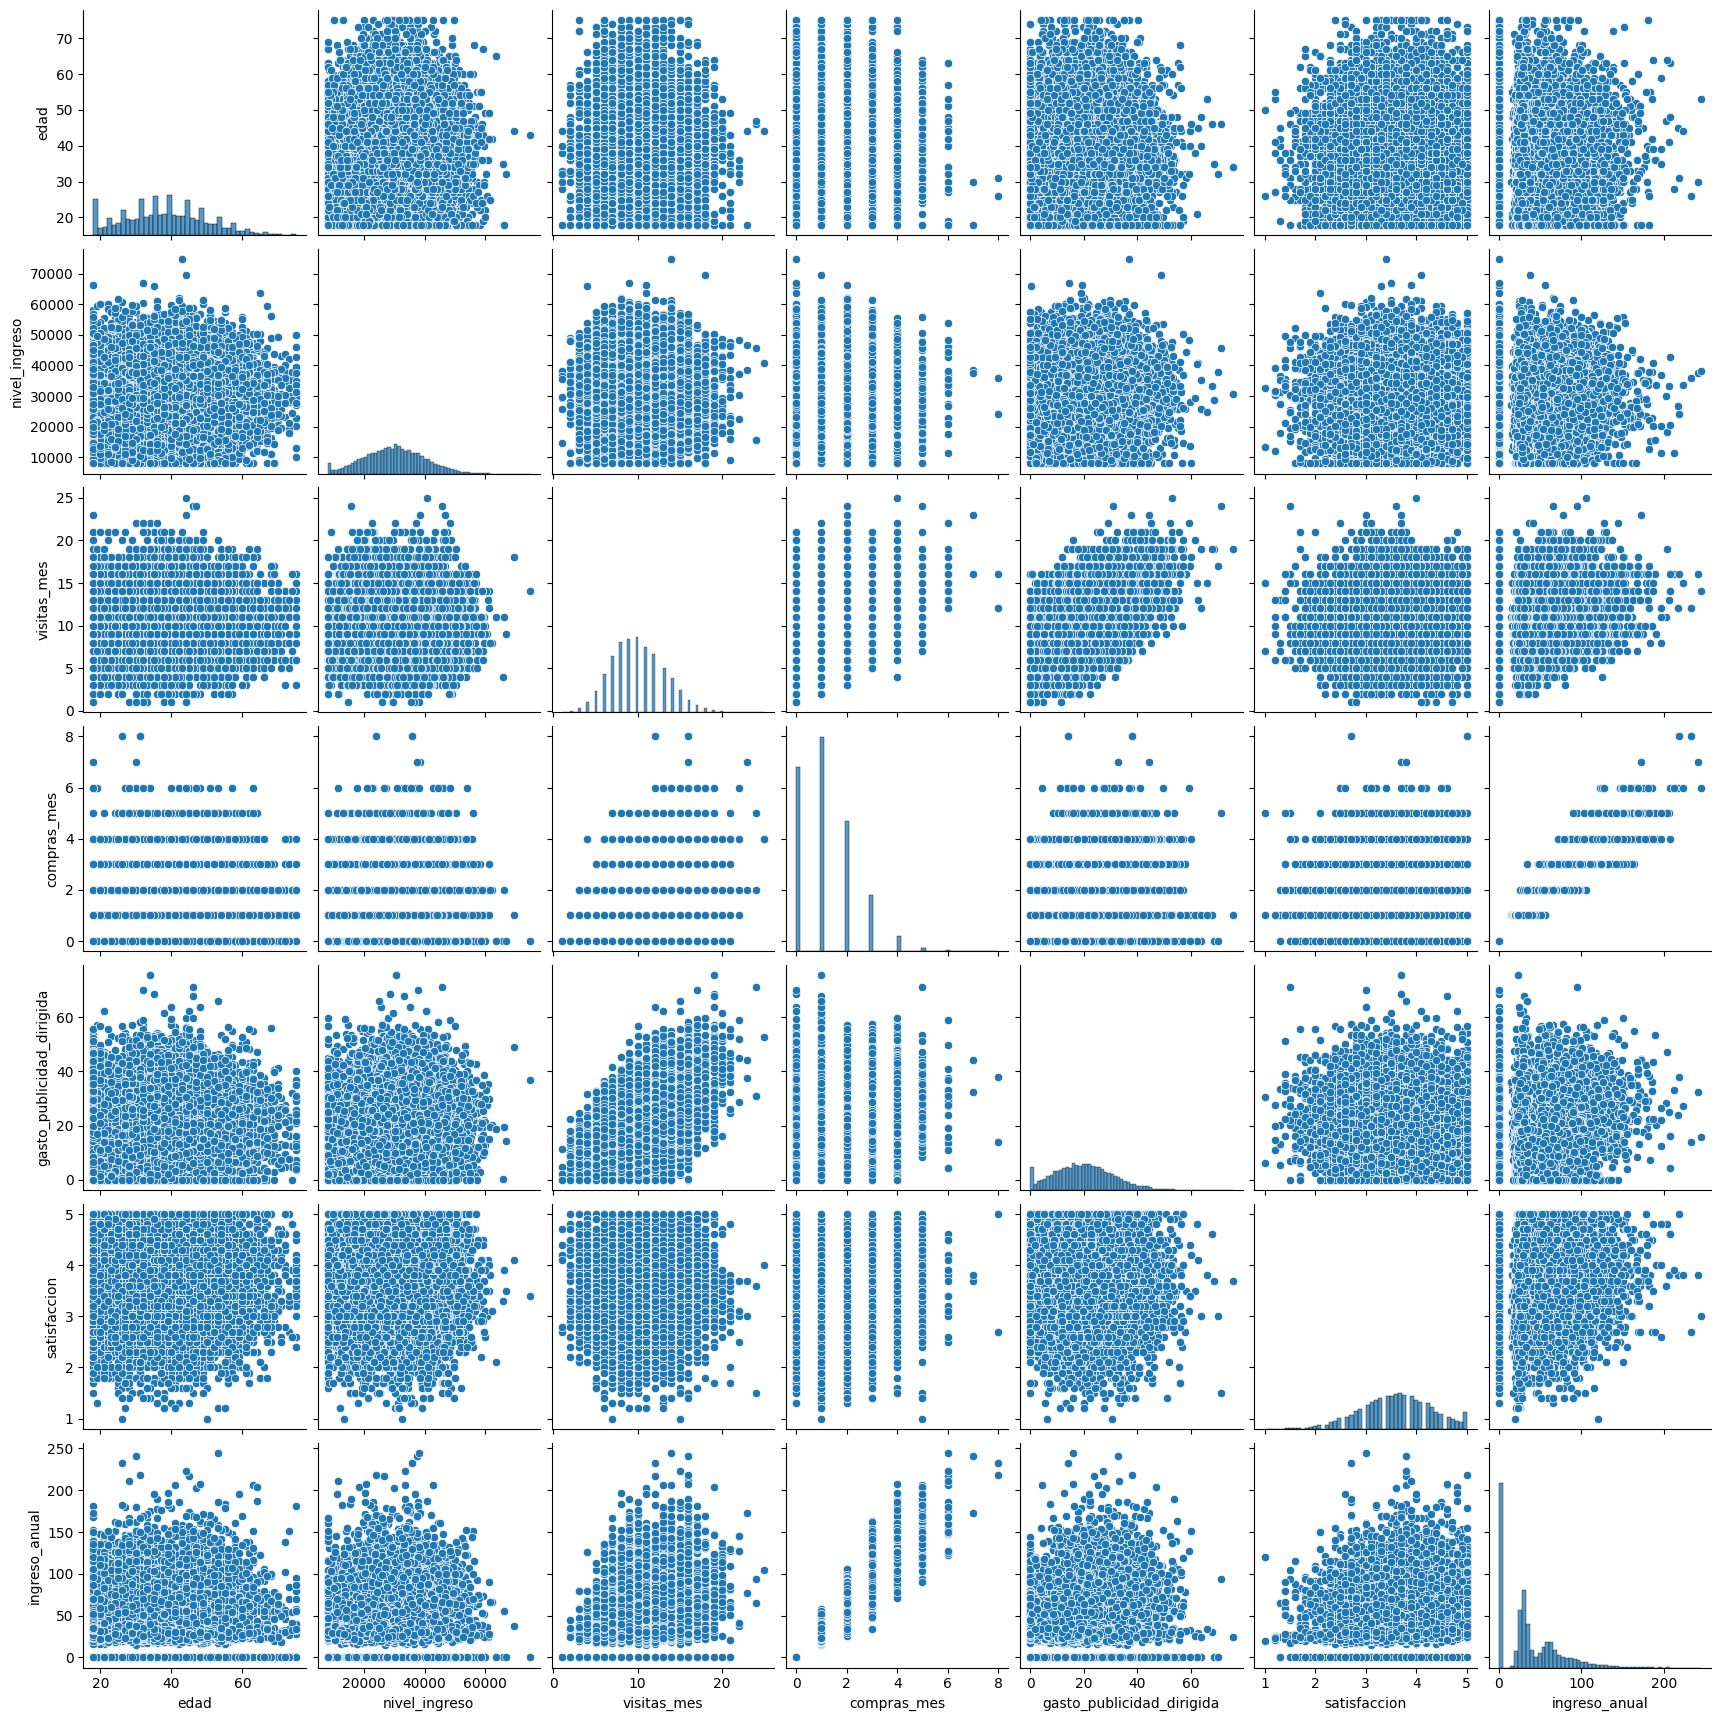

In [ ]:
# Pair plot — visual overview of all numeric variable relationships
sns.pairplot(variables_numericas)

### Key Variable Pair Scatterplots

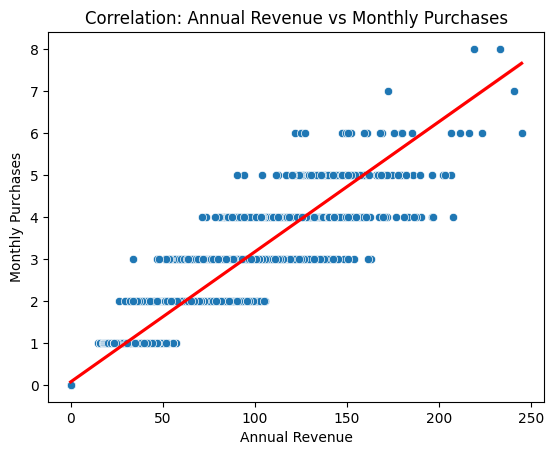

In [ ]:
# Scatterplot: Annual Revenue vs Monthly Purchases (strong positive association)
sns.scatterplot(data=df, x="ingreso_anual", y="compras_mes")
sns.regplot(data=df, x="ingreso_anual", y="compras_mes", scatter=False, color="red")
plt.xlabel("Annual Revenue")
plt.ylabel("Monthly Purchases")
plt.title("Correlation: Annual Revenue vs Monthly Purchases")
plt.show()

**Annual Revenue vs. Monthly Purchases — r = 0.97 (Pearson)**

- **Direction:** Strong positive — the regression line rises steeply from left to right.
- **Dispersion:** Low to moderate — data points cluster tightly around the regression line across the full range.
- **Outliers:** A few isolated points in the upper right (high values on both axes), but they do not distort the overall trend.
- **Structural pattern:** The discrete nature of `compras_mes` (integer values 0–8) creates vertical bands of points. Within each band, `ingreso_anual` shows consistent upward scaling.

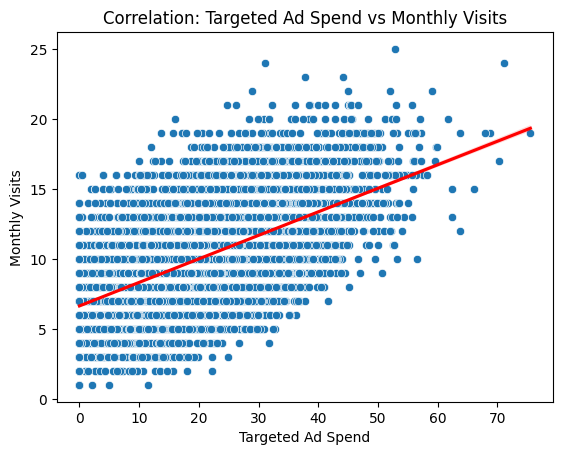

In [ ]:
# Scatterplot: Ad Spend vs Monthly Visits (strong secondary association)
sns.scatterplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes")
sns.regplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes", scatter=False, color="red")
plt.xlabel("Targeted Ad Spend")
plt.ylabel("Monthly Visits")
plt.title("Correlation: Targeted Ad Spend vs Monthly Visits")
plt.show()

**Targeted Ad Spend vs. Monthly Visits — r = 0.58 (Spearman)**

- **Direction:** Positive — ascending trend line with moderate slope.
- **Dispersion:** High — the point cloud is wide and diffuse around the regression line.
- **Outliers:** Isolated points in the upper tail of the X-axis (ad spend > 60–70) with sparse representation.
- **Structural pattern:** Observations are densest in the 0–40 ad spend range, with `visitas_mes` distributed between 5 and 20 within that range.
- **Collinearity note:** Moderate — this pair warrants caution in multivariate modeling.

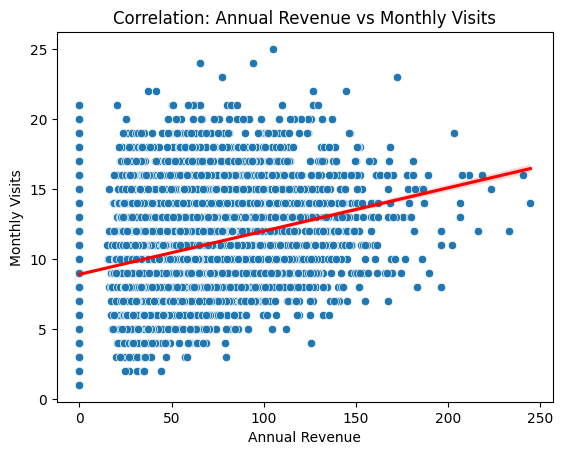

In [ ]:
# Scatterplot: Annual Revenue vs Monthly Visits (moderate association)
sns.scatterplot(data=df, x="ingreso_anual", y="visitas_mes")
sns.regplot(data=df, x="ingreso_anual", y="visitas_mes", scatter=False, color="red")
plt.xlabel("Annual Revenue")
plt.ylabel("Monthly Visits")
plt.title("Correlation: Annual Revenue vs Monthly Visits")
plt.show()

**Annual Revenue vs. Monthly Visits — r = 0.34 (Pearson)**

- **Direction:** Weak positive — ascending trend with low slope.
- **Dispersion:** High — the point cloud extends broadly on both axes.
- **Outliers:** Scattered points at the upper end of `visitas_mes` (> 20) and the far right of `ingreso_anual` (> 200), without forming defined clusters.
- **Structural pattern:** No clear structure visible. Data distributes relatively uniformly across the plane.
- **Collinearity note:** Low.

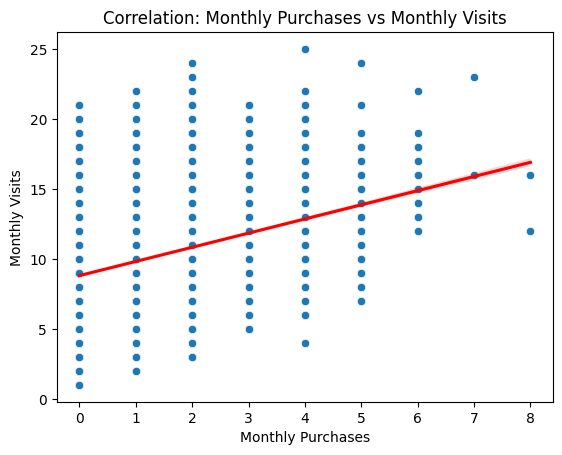

In [ ]:
# Scatterplot: Monthly Purchases vs Monthly Visits (moderate association)
sns.scatterplot(data=df, x="compras_mes", y="visitas_mes")
sns.regplot(data=df, x="compras_mes", y="visitas_mes", scatter=False, color="red")
plt.xlabel("Monthly Purchases")
plt.ylabel("Monthly Visits")
plt.title("Correlation: Monthly Purchases vs Monthly Visits")
plt.show()

**Monthly Purchases vs. Monthly Visits — r = 0.35 (Pearson)**

- **Direction:** Weak positive — slight upward trend from left to right.
- **Dispersion:** High — for each discrete value of `compras_mes`, the range of `visitas_mes` spans nearly its full extent (~2 to ~23).
- **Outliers:** One visible isolated point with `visitas_mes` ≈ 25 at `compras_mes` = 4; another in the upper right zone.
- **Structural pattern:** The discrete nature of `compras_mes` generates vertical columns of points (0 to 8). High within-column variability in `visitas_mes` limits the practical predictive value of this pair.

## Section 4 — Correlation Coefficients and Statistical Evidence

In this section, numerical coefficients are calculated to support the visual patterns identified in Section 3. The appropriate correlation method is selected based on the nature of each variable pair.

### Pearson and Spearman Correlations

In [ ]:
# Pearson correlation: Annual Revenue vs Monthly Purchases
print("Pearson r (ingreso_anual vs compras_mes):")
print(round(df["ingreso_anual"].corr(df["compras_mes"], method="pearson"), 4))

Pearson r (ingreso_anual vs compras_mes):
0.9671


In [ ]:
# Spearman correlation: Targeted Ad Spend vs Monthly Visits
print("Spearman rho (gasto_publicidad_dirigida vs visitas_mes):")
print(round(df["gasto_publicidad_dirigida"].corr(df["visitas_mes"], method="spearman"), 4))

Spearman rho (gasto_publicidad_dirigida vs visitas_mes):
0.5593


**Pearson: `ingreso_anual` vs `compras_mes` — r = 0.9671**

Pearson was selected because the scatterplot showed a clear linear relationship, with homogeneous variance across the range and both variables on a sufficiently continuous scale. The result indicates a very high positive linear association: as `compras_mes` increases by one unit, `ingreso_anual` tends to increase proportionally and consistently.

**Spearman: `gasto_publicidad_dirigida` vs `visitas_mes` — ρ = 0.5593**

Spearman was selected due to the right-skewed distribution of `gasto_publicidad_dirigida` and the presence of outliers in the upper tail. This method is robust to non-normal distributions and rank-based monotonic relationships. The result confirms a moderate positive monotonic association between ad spend and monthly visits.

### Point-Biserial Correlation

In [ ]:
# Calcular correlación entre variables relevantes
# Se segmenta en lista dentro de la variable "pares", haciendo los pares en columnas binarias (miembro_premium y abandono) y numéricas.
pares = [
    ("miembro_premium", "ingreso_anual"),
    ("miembro_premium", "nivel_ingreso"),
    ("miembro_premium", "compras_mes"),
    ("miembro_premium", "satisfaccion"),
    ("miembro_premium", "edad"),
    ("abandono", "ingreso_anual"),
    ("abandono", "nivel_ingreso"),
    ("abandono", "satisfaccion"),
    ("abandono", "compras_mes"),
    ("abandono", "edad"),
    ("abandono", "visitas_mes")
]

# se genera función para analizar la correlación Point-Biserial

for binaria, continua in pares:
    corr, pvalue = stats.pointbiserialr(df[binaria], df[continua])
    print(f"{binaria} vs {continua} → r = {corr:.4f} | p-value = {pvalue:.4f}")

miembro_premium vs ingreso_anual → r = 0.0931 | p-value = 0.0000
miembro_premium vs nivel_ingreso → r = -0.0056 | p-value = 0.4930
miembro_premium vs compras_mes → r = 0.0034 | p-value = 0.6744
miembro_premium vs satisfaccion → r = 0.0257 | p-value = 0.0016
miembro_premium vs edad → r = 0.0046 | p-value = 0.5728
abandono vs ingreso_anual → r = -0.0028 | p-value = 0.7295
abandono vs nivel_ingreso → r = 0.0059 | p-value = 0.4722
abandono vs satisfaccion → r = -0.0238 | p-value = 0.0035
abandono vs compras_mes → r = 0.0083 | p-value = 0.3099
abandono vs edad → r = -0.0115 | p-value = 0.1590
abandono vs visitas_mes → r = -0.0089 | p-value = 0.2734


**Point-Biserial Results — Binary vs. Continuous Variables**

Neither `miembro_premium` nor `abandono` shows a practically meaningful linear association with any of the continuous variables analyzed. All coefficients fall below the minimum relevance threshold of **|r| > 0.10**.

The statistically significant p-values observed for some pairs are a byproduct of the large sample size (n = 15,000) and should not be interpreted as evidence of practically important relationships. Statistical significance and practical magnitude must be evaluated independently.

### Cramér's V — Categorical Associations

In [ ]:
# Función para calcular V de Cramér
def cramers_v(var1, var2):
    # Tabla de contingencia
    tabla = pd.crosstab(var1, var2)

    # Chi-cuadrado
    chi2, pvalue, dof, expected = chi2_contingency(tabla)

    # N total y dimensiones
    n = tabla.sum().sum()
    r, k = tabla.shape

    # V de Cramér
    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

    return round(v, 4), round(pvalue, 4)

# Pares categóricos relevantes
pares = [
    ("tipo_dispositivo", "region"),
    ("tipo_dispositivo", "miembro_premium"),
    ("tipo_dispositivo", "abandono"),
    ("region",           "miembro_premium"),
    ("region",           "abandono"),
    ("miembro_premium",  "abandono"),
]

for v1, v2 in pares:
    v, p = cramers_v(df[v1], df[v2])
    print(f"{v1} vs {v2} → V = {v} | p-value = {p}")


tipo_dispositivo vs region → V = 0.0124 | p-value = 0.5965
tipo_dispositivo vs miembro_premium → V = 0.0197 | p-value = 0.054
tipo_dispositivo vs abandono → V = 0.0072 | p-value = 0.6746
region vs miembro_premium → V = 0.0126 | p-value = 0.4989
region vs abandono → V = 0.0154 | p-value = 0.3117
miembro_premium vs abandono → V = 0.1202 | p-value = 0.0


**Cramér's V Results — Categorical Variable Pairs**

Of the six categorical pairs evaluated, five show no meaningful association (V < 0.02, p > 0.05). The only pair with a detectable signal is `miembro_premium` vs `abandono` (V = 0.1202, p < 0.0001), reflecting a statistically significant but low-magnitude association.

Neither `tipo_dispositivo` nor `region` shows meaningful association with any other categorical variable in the dataset.

## Section 5 — Business Interpretation of Results

**Core business question:** *What customer behavioral factors are most strongly associated with annual revenue generated?*

The exploratory correlation analysis applied across 15,000 records and 12 variables identifies `compras_mes` as the only factor with a strong, quantifiable association with `ingreso_anual` (Pearson r = 0.9671). All other behavioral variables — `visitas_mes`, `gasto_publicidad_dirigida`, `miembro_premium`, and `satisfaccion` — show low or negligible association with the target variable.

### Key Findings

### Finding 1 — Very Strong Association Between Monthly Purchases and Annual Revenue

- **Visual evidence:** The scatterplot shows a narrow, ascending point cloud with a clear linear fit across the full range, consistent low dispersion, and no structural anomalies.
- **Numerical evidence:** Pearson r = 0.9671 (p < 0.0001), calculated over n = 15,000 observations.
- **Interpretation:** Of all variables analyzed, `compras_mes` exhibits the strongest linear association with `ingreso_anual`. The coefficient indicates that approximately 93.5% of the joint variation between both variables follows a direct linear pattern. This is the most actionable signal identified in the dataset.
- **Business implication:** Strategies aimed at increasing purchase frequency are the most likely behavioral lever for improving annual revenue per customer.

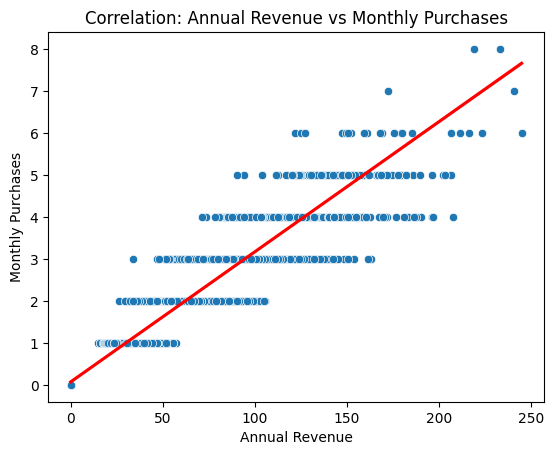

In [ ]:
# Scatterplot: Annual Revenue vs Monthly Purchases (Finding 1)
sns.scatterplot(data=df, x="ingreso_anual", y="compras_mes")
sns.regplot(data=df, x="ingreso_anual", y="compras_mes", scatter=False, color="red")
plt.xlabel("Annual Revenue")
plt.ylabel("Monthly Purchases")
plt.title("Correlation: Annual Revenue vs Monthly Purchases")
plt.show()

### Finding 2 — Moderate Association Between Targeted Ad Spend and Monthly Visits

- **Visual evidence:** The scatterplot shows a wide, diffuse point cloud with a moderately ascending regression line. Observation density is highest in the 0–40 ad spend range, with outliers in the upper tail (> 60).
- **Numerical evidence:** Spearman ρ = 0.5593 (p < 0.0001). Spearman was selected due to the right-skewed distribution and presence of outliers in `gasto_publicidad_dirigida`.
- **Interpretation:** A positive monotonic relationship exists between targeted ad spend and monthly platform visits. The moderate coefficient indicates a directional signal, but with high individual-level variability.
- **Business implication:** Targeted advertising investment shows a positive but imperfect association with visit frequency. Returns may vary significantly across customer segments.

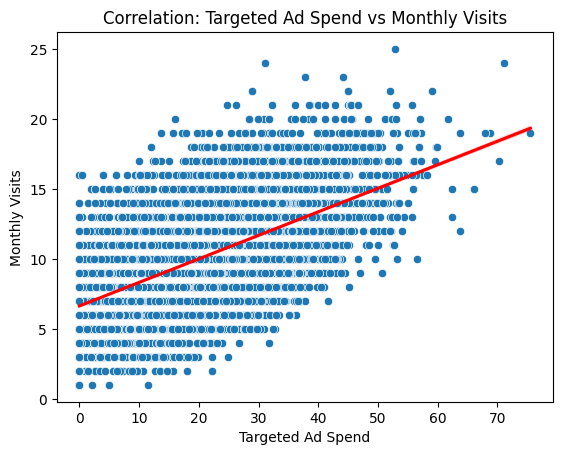

In [ ]:
# Scatterplot: Targeted Ad Spend vs Monthly Visits (Finding 2)
sns.scatterplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes")
sns.regplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes", scatter=False, color="red")
plt.xlabel("Targeted Ad Spend")
plt.ylabel("Monthly Visits")
plt.title("Correlation: Targeted Ad Spend vs Monthly Visits")
plt.show()

### Finding 3 — No Practical Association Between Premium Membership and Behavioral Variables

- **Numerical evidence:** Point-Biserial correlations: `miembro_premium` vs `ingreso_anual` r = 0.0931 (p < 0.0001); vs `satisfaccion` r = 0.0257 (p = 0.0016); vs `nivel_ingreso` r = −0.0056 (p = 0.493); vs `compras_mes` r = 0.0034 (p = 0.674).
- **Interpretation:** The only coefficient approaching the low-magnitude threshold is `miembro_premium` vs `ingreso_anual` (r = 0.093), which still falls below |r| = 0.10. Statistically significant p-values in a dataset of n = 15,000 do not constitute evidence of practical relevance when effect sizes are this small.
- **Business implication:** Based on the available data, premium membership status does not function as a meaningful differentiator across the behavioral and value variables analyzed.

### Finding 4 — No Practical Association Between Churn and Continuous Variables

- **Numerical evidence:** Point-Biserial correlations: `abandono` vs `satisfaccion` r = −0.0238 (p = 0.0035); vs `compras_mes` r = 0.0083 (p = 0.310); vs `ingreso_anual` r = −0.0028 (p = 0.730); vs `nivel_ingreso` r = 0.0059 (p = 0.472).
- **Interpretation:** No coefficient exceeds the low-magnitude threshold (|r| < 0.10). The only statistically significant association, `abandono` vs `satisfaccion` (r = −0.024), has a negligible effect size given the sample size.
- **Business implication:** The continuous variables available in this dataset do not allow robust linear characterization of the churned customer segment. Non-linear techniques or segmentation models are recommended for further analysis of churn drivers.

### Finding 5 — Low but Detectable Association Between Premium Membership and Churn

- **Numerical evidence:** Cramér's V = 0.1202 (p < 0.0001) over n = 15,000. This is the only categorical pair to reach statistical significance. All remaining categorical pairs yielded V < 0.02 with p > 0.05.
- **Interpretation:** A statistically significant association exists between `miembro_premium` and `abandono`, with low magnitude according to standard Cramér's V thresholds. One variable's categories do not reliably predict the other's, but this pair represents the strongest signal detected in the categorical analysis.
- **Business implication:** `miembro_premium` vs `abandono` is the only categorical pair with a detectable signal. Its low magnitude suggests that membership status alone is not a robust predictor of churn. A cross-tabulated analysis disaggregating premium churn rates by satisfaction level is recommended to determine whether dissatisfaction with the premium service is driving exits.

## Section 6 — Limitations and Next Steps

### Limitations

- **Correlation ≠ Causation** — All coefficients computed (Pearson, Spearman, Point-Biserial, and Cramér's V) measure the strength and direction of statistical association. No finding in this analysis supports a causal interpretation.

- **Large sample size effect** — With n = 15,000 observations, statistical power is very high. This produces significant p-values even for associations with negligible effect sizes (r < 0.10). Statistical significance and practical relevance must always be evaluated independently.

- **Potential Simpson's Paradox** — Global correlations — particularly `compras_mes` vs `ingreso_anual` (r = 0.967) — have not been verified within subgroups defined by `region`, `tipo_dispositivo`, or `miembro_premium`. The global relationship may not be homogeneous across segments.

- **Variables not included** — The analysis is limited to the 12 variables available in the dataset. External factors not captured (seasonality, one-time campaigns, macroeconomic context) may be influencing the relationships observed.

---

### Next Steps

**Step 1 — Simpson's Paradox Verification**
- Disaggregate the primary correlations by `region`, `tipo_dispositivo`, and `miembro_premium` to evaluate whether the global relationships remain stable within each subgroup.
- Prioritize the `compras_mes` vs `ingreso_anual` pair given its high coefficient.

**Step 2 — Segmentation and Subgroup Analysis**
- Apply clustering techniques (K-Means or hierarchical clustering) to behavioral variables to identify differentiated customer profiles.
- Evaluate whether the globally observed correlation patterns replicate or diverge within each segment.

**Step 3 — Predictive Modeling**
- Develop a regression model using `ingreso_anual` as the dependent variable, incorporating the highest-association variables identified: `compras_mes`, `visitas_mes`, and `gasto_publicidad_dirigida`.
- Evaluate multicollinearity before simultaneously including `compras_mes` and other correlated predictors, given the r = 0.967 observed between `compras_mes` and `ingreso_anual`.